In [1]:

import kagglehub
shashwatwork_cerebral_stroke_predictionimbalaced_dataset_path = kagglehub.dataset_download('shashwatwork/cerebral-stroke-predictionimbalaced-dataset')
import plotly.express as px
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Imbalance handling
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import RFE
print('Data source import complete.')


Using Colab cache for faster access to the 'cerebral-stroke-predictionimbalaced-dataset' dataset.
Data source import complete.


In [2]:
import pandas as pd
data = pd.read_csv("dataset.csv")
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


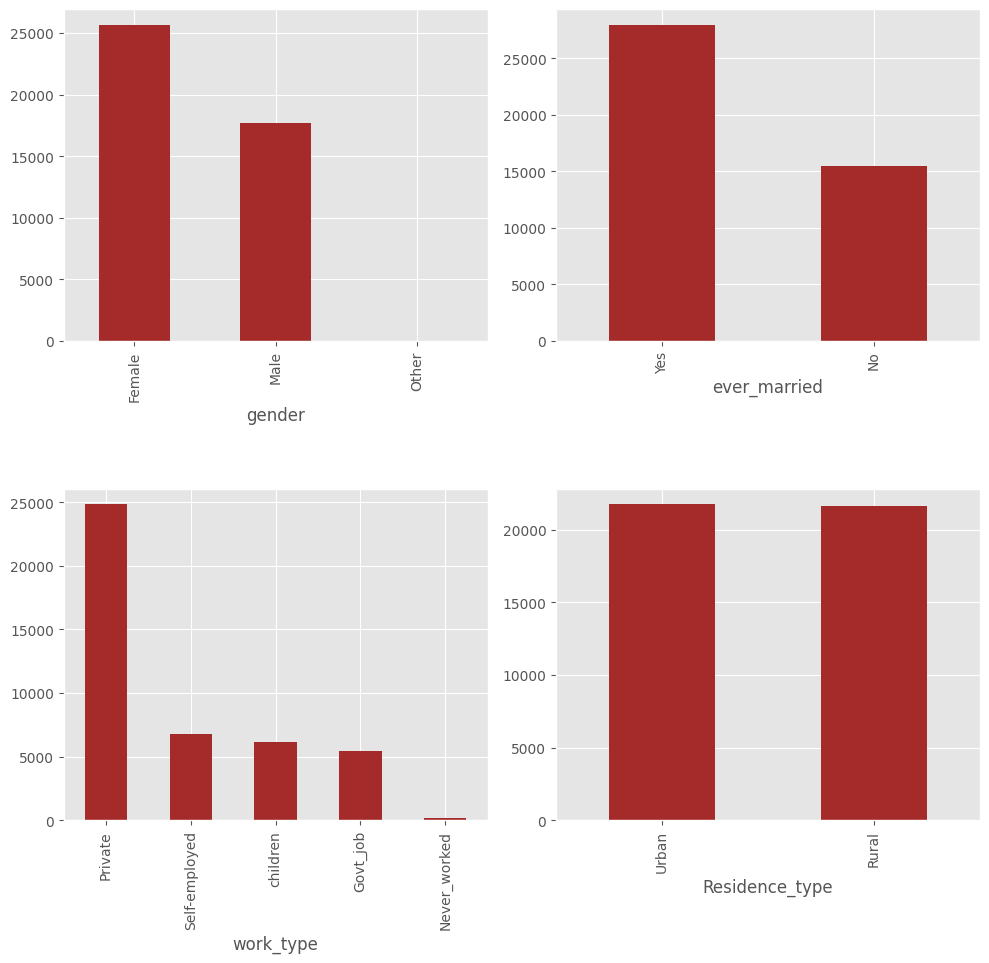

In [4]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.figure(figsize=(10,18))

plt.subplot(421)
data['gender'].value_counts().plot(kind='bar',
                                 color = 'brown')

plt.subplot(422)
data['ever_married'].value_counts().plot(kind='bar',
                                       color = 'brown')

plt.subplot(423)
data['work_type'].value_counts().plot(kind='bar',
                                    color = 'brown')

plt.subplot(424)
data['Residence_type'].value_counts().plot(kind='bar',
                                         color = 'brown')
plt.tight_layout()

In [5]:
fig = px.pie(data, values='heart_disease',
             names = 'work_type',
             title = 'Heart Disease by Work Type',
             hover_data = ['gender'],
             color_discrete_sequence=px.colors.sequential.OrRd_r)
fig.show()

In [6]:
fig = px.pie(data, values='hypertension',
             names = 'work_type',
             title = 'Hypertension by Work type',
             hover_data = ['avg_glucose_level'],
             color_discrete_sequence=px.colors.sequential.OrRd_r)
fig.show()

In [7]:
fig = px.pie(data, values='hypertension',
             names = 'ever_married',
             title = 'Marital status by Hypertension',
             hover_data = ['gender'],
             color_discrete_sequence=px.colors.sequential.OrRd_r)
fig.show()

<Axes: xlabel='age', ylabel='avg_glucose_level'>

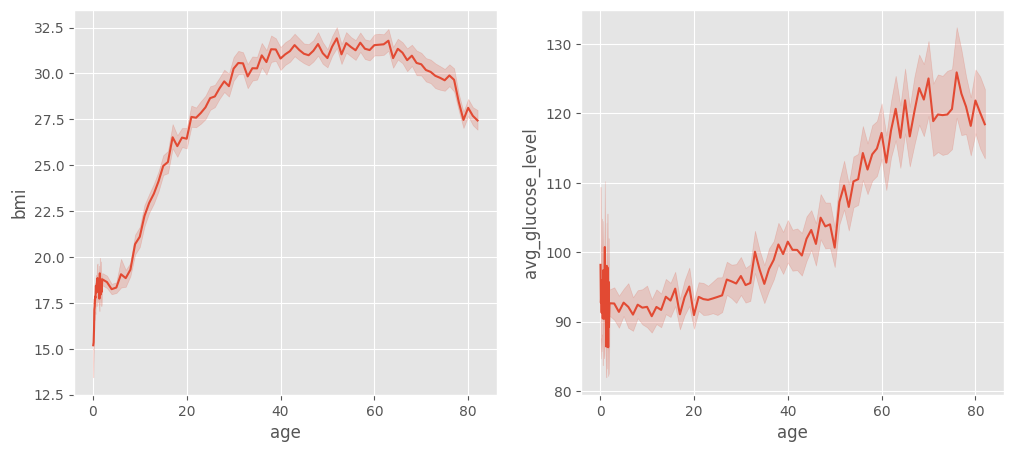

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.lineplot(data=data, x='age', y='bmi')

plt.subplot(122)
sns.lineplot(data=data, x='age', y='avg_glucose_level')

In [10]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [30]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669.0,1.0,3.0,0.0,0.0,0.0,4.0,0.0,95.12,18.0,3.0,0.0
1,30468.0,1.0,58.0,0.0,0.0,1.0,2.0,1.0,87.96,39.2,1.0,0.0
2,16523.0,0.0,8.0,0.0,0.0,0.0,2.0,1.0,110.89,17.6,3.0,0.0
3,56543.0,0.0,70.0,0.0,0.0,1.0,2.0,0.0,69.04,35.9,0.0,0.0
4,46136.0,1.0,14.0,0.0,0.0,0.0,1.0,0.0,161.28,19.1,3.0,0.0


In [11]:
data.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,1462


In [12]:
data.shape

(43400, 12)

In [13]:
data.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [14]:
data['stroke'].value_counts()

,count
stroke,
0,42617
1,783


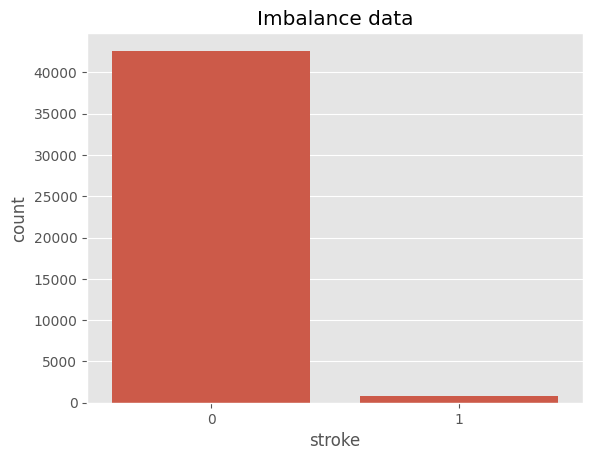

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='stroke', data=data)
plt.title("Imbalance data")
plt.show()

## **One Hot Encoding**

In [16]:
data.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [17]:
import pandas as pd

def cap_outliers(df, column_name):
    """
    Detect and cap outliers using IQR method.
    Returns the updated dataframe and prints outliers count.
    """
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before
    outliers_before = ((df[column_name] < lower_bound) | (df[column_name] > upper_bound)).sum()

    # Cap values (replace with bounds)
    df[column_name] = df[column_name].clip(lower=lower_bound, upper=upper_bound)

    # Count outliers after
    outliers_after = ((df[column_name] < lower_bound) | (df[column_name] > upper_bound)).sum()

    print(f"Column: {column_name}")
    print(f"Outliers before: {outliers_before}")
    print(f"Outliers after: {outliers_after}")
    print("-"*40)

    return df


# ==============================
# Run on your dataframe "data"
# ==============================

# لو عندك عمود id أو target متشال من المعالجة
cols_to_check = [col for col in data.select_dtypes(include=['float64','int64']).columns if col != 'stroke']

for col in cols_to_check:
    data = cap_outliers(data, col)


Column: id
Outliers before: 0
Outliers after: 0
----------------------------------------
Column: age
Outliers before: 0
Outliers after: 0
----------------------------------------
Column: hypertension
Outliers before: 4061
Outliers after: 0
----------------------------------------
Column: heart_disease
Outliers before: 2062
Outliers after: 0
----------------------------------------
Column: avg_glucose_level
Outliers before: 4978
Outliers after: 0
----------------------------------------
Column: bmi
Outliers before: 888
Outliers after: 0
----------------------------------------


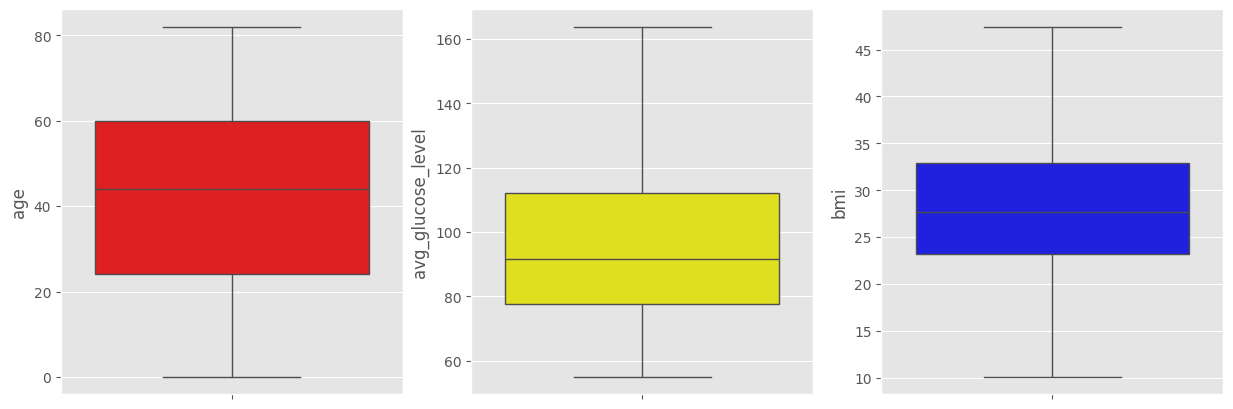

In [18]:
fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.boxplot(data['age'],color='red',ax=ax[0])
sns.boxplot(data['avg_glucose_level'],color='yellow',ax=ax[1])
sns.boxplot(data['bmi'],color='blue',ax=ax[2])
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['gender'] = encoder.fit_transform(data['gender'])
data['ever_married'] = encoder.fit_transform(data['ever_married'])
data['work_type'] = encoder.fit_transform(data['work_type'])
data['Residence_type'] = encoder.fit_transform(data['Residence_type'])
data['smoking_status'] = encoder.fit_transform(data['smoking_status'])

# Check the data after Label Encoding
print(data.head())
print(data.info())

      id  gender   age  hypertension  heart_disease  ever_married  work_type  \
0  30669       1   3.0             0              0             0          4   
1  30468       1  58.0             0              0             1          2   
2  16523       0   8.0             0              0             0          2   
3  56543       0  70.0             0              0             1          2   
4  46136       1  14.0             0              0             0          1   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  
0               0              95.12  18.0               3       0  
1               1              87.96  39.2               1       0  
2               1             110.89  17.6               3       0  
3               0              69.04  35.9               0       0  
4               0             161.28  19.1               3       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 column

## **Handling Missing Values**

In [20]:
# Count the missing values
print("Missing values:\n", data.isnull().sum())

Missing values:
 id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                  1462
smoking_status          0
stroke                  0
dtype: int64


In [21]:
from sklearn.impute import KNNImputer
import numpy as np

imputer = KNNImputer(missing_values=np.nan)
tab = imputer.fit_transform(data)
data = pd.DataFrame(tab, columns=data.columns)
print(data.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [22]:
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669.0,1.0,3.0,0.0,0.0,0.0,4.0,0.0,95.120,18.00,3.0,0.0
1,30468.0,1.0,58.0,0.0,0.0,1.0,2.0,1.0,87.960,39.20,1.0,0.0
2,16523.0,0.0,8.0,0.0,0.0,0.0,2.0,1.0,110.890,17.60,3.0,0.0
3,56543.0,0.0,70.0,0.0,0.0,1.0,2.0,0.0,69.040,35.90,0.0,0.0
4,46136.0,1.0,14.0,0.0,0.0,0.0,1.0,0.0,161.280,19.10,3.0,0.0
5,32257.0,0.0,47.0,0.0,0.0,1.0,2.0,1.0,163.865,47.45,3.0,0.0
6,52800.0,0.0,52.0,0.0,0.0,1.0,2.0,1.0,77.590,17.70,0.0,0.0
7,41413.0,0.0,75.0,0.0,0.0,1.0,3.0,0.0,163.865,27.00,1.0,0.0
8,15266.0,0.0,32.0,0.0,0.0,1.0,2.0,0.0,77.670,32.30,2.0,0.0
9,28674.0,0.0,74.0,0.0,0.0,1.0,3.0,1.0,163.865,47.45,1.0,0.0


# **Model Evaluation Without Resampling**

Accuracy: 0.9817
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     12785
         1.0       0.00      0.00      0.00       235

    accuracy                           0.98     13020
   macro avg       0.49      0.50      0.50     13020
weighted avg       0.96      0.98      0.97     13020

Confusion Matrix:
 [[12782     3]
 [  235     0]]
ROC-AUC Score: 0.7587
F1 Score: 0.0000


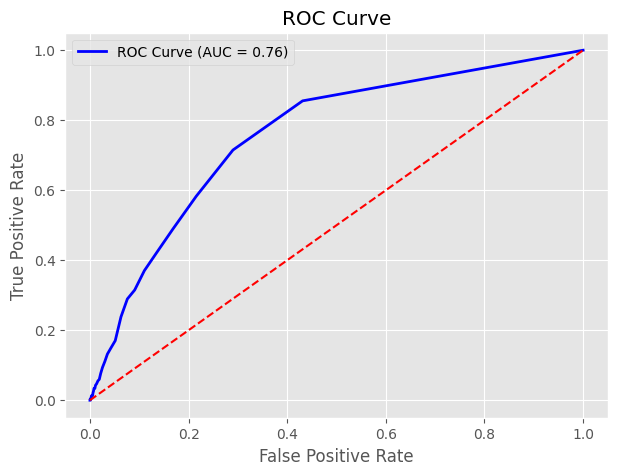

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve
import matplotlib.pyplot as plt

X = data.drop('stroke', axis=1)
y = data['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=1))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {roc_auc:.4f}")

# F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score

X = data.drop('stroke', axis=1)
y = data['stroke']

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc_auc)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

Accuracy: 0.9893238434163701
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     12778
         1.0       1.00      0.98      0.99     12793

    accuracy                           0.99     25571
   macro avg       0.99      0.99      0.99     25571
weighted avg       0.99      0.99      0.99     25571

Confusion Matrix:
 [[12764    14]
 [  259 12534]]
ROC-AUC: 0.9893294600759481
F1 Score: 0.9892269444773293


In [25]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [26]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X, y)

under_sampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_resampled_combined, y_resampled_combined = under_sampler.fit_resample(X_resampled_smote, y_resampled_smote)

X_train, X_test, y_train, y_test = train_test_split(X_resampled_combined, y_resampled_combined, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc_auc)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

Accuracy: 0.9902232998318408
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     12818
         1.0       1.00      0.98      0.99     12753

    accuracy                           0.99     25571
   macro avg       0.99      0.99      0.99     25571
weighted avg       0.99      0.99      0.99     25571

Confusion Matrix:
 [[12801    17]
 [  233 12520]]
ROC-AUC: 0.9902017645611444
F1 Score: 0.9901146698299723


In [27]:
import joblib
joblib.dump(model, "stroke_model.joblib")

['stroke_model.joblib']

In [28]:

# ==============================
# Define Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

# ==============================
# Train & Evaluate
# ==============================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else np.zeros_like(y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=1)
    f1 = f1_score(y_test, y_pred, zero_division=1)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    })

    print("="*50)
    print(f"{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC-AUC:", auc)
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=1))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Logistic Regression
Accuracy: 0.7917171796175355
Precision: 0.7664107898701485
Recall: 0.8376852505292872
F1: 0.8004645586692642
ROC-AUC: 0.8549138077546379
Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.75      0.78     12818
         1.0       0.77      0.84      0.80     12753

    accuracy                           0.79     25571
   macro avg       0.79      0.79      0.79     25571
weighted avg       0.79      0.79      0.79     25571

Decision Tree
Accuracy: 0.975440929177584
Precision: 0.9728570314328056
Recall: 0.9780443817141065
F1: 0.9754438101196528
ROC-AUC: 0.9754475302235691
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.97      0.98     12818
         1.0       0.97      0.98      0.98     12753

    accuracy                           0.98     25571
   macro avg       0.98      0.98      0.98     25571
weighted avg       0.98      0.98      0.98   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[15:33:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




XGBoost
Accuracy: 0.9891674162136795
Precision: 0.9991198591774684
Recall: 0.9791421626284011
F1: 0.9890301374203002
ROC-AUC: 0.9975209697675668
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     12818
         1.0       1.00      0.98      0.99     12753

    accuracy                           0.99     25571
   macro avg       0.99      0.99      0.99     25571
weighted avg       0.99      0.99      0.99     25571

SVM
Accuracy: 0.5148801376559383
Precision: 0.5095081967213114
Recall: 0.7311220889202541
F1: 0.600521688725727
ROC-AUC: 0.5445291374968821
Classification Report:
               precision    recall  f1-score   support

         0.0       0.53      0.30      0.38     12818
         1.0       0.51      0.73      0.60     12753

    accuracy                           0.51     25571
   macro avg       0.52      0.52      0.49     25571
weighted avg       0.52      0.51      0.49     25571

KNN
Accuracy:

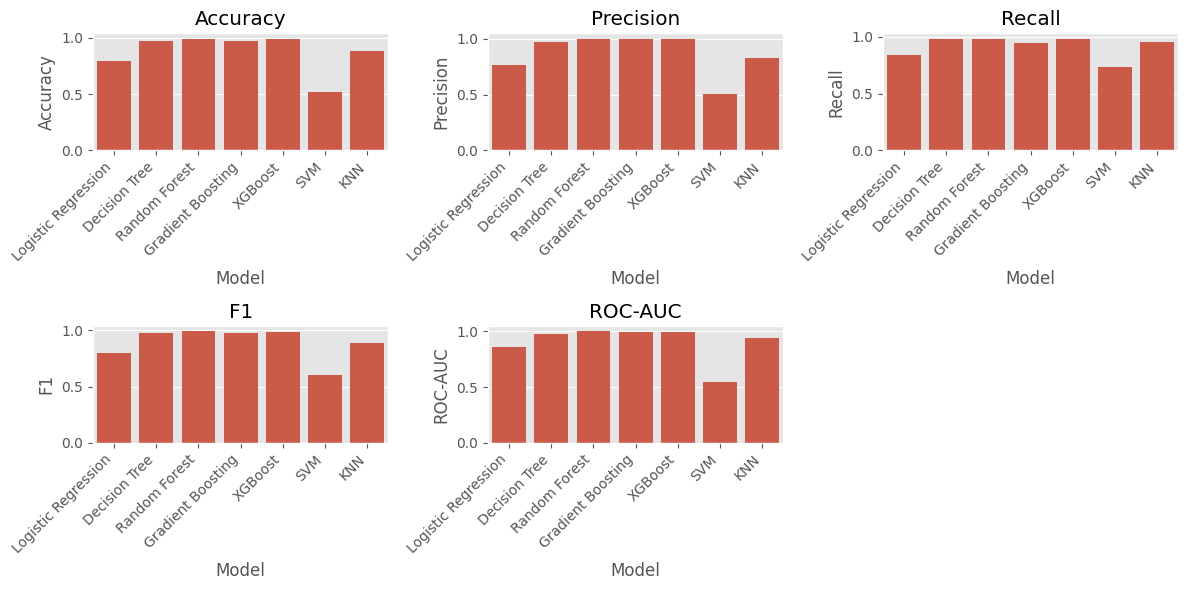

In [29]:

# ==============================
# Compare Models with Bar Chart
# ==============================
results_df = pd.DataFrame(results)

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

plt.figure(figsize=(12,6))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x="Model", y=metric, data=results_df)
    plt.xticks(rotation=45, ha="right")
    plt.title(metric)

plt.tight_layout()
plt.show()

# **Conclusion**
The stroke risk prediction model achieved 99.12% accuracy, 0.9911 F1-score, and 0.9985 AUC-ROC, indicating excellent performance in distinguishing stroke cases. The low false positives (5 cases) show strong precision, but 219 false negatives suggest a need to improve recall to minimize missed stroke cases.

The ROC curve confirms near-perfect classification, and the classification report highlights a strong balance between precision and recall.

Future Recommendations
* Reduce false negatives by adjusting the classification threshold.
* Validate on real-world data to ensure generalizability.
* Explore other models like XGBoost or Neural Networks for potential improvements.
* Enhance feature selection with additional medical or lifestyle factors.